In [2]:
import numpy as np
from scipy.spatial.transform import Rotation as R
import pandas as pd
import os
import sys
PATH = os.getcwd()
module_dir = os.path.abspath(f"{PATH}/../sam-3d-objects/notebook/")
sys.path.append(module_dir)
from inference import Inference, ready_gaussian_for_video_rendering, load_image, load_masks, display_image, make_scene, render_video, interactive_visualizer
import torch
from trimesh import transformations
from pytorch3d.transforms import quaternion_to_matrix, Transform3d


def get_matrix_from_row(row):
    """
    row: a dictionary or pandas row containing 
    tx, ty, tz, qx, qy, qz, qw
    """
    # 1. Extract Translation
    t = np.array([row['tx'], row['ty'], row['tz']])
    
    # 2. Extract Rotation from Quaternion
    # Note: Scipy uses [x, y, z, w] order by default
    quat = [row['qx'], row['qy'], row['qz'], row['qw']]
    r_mat = R.from_quat(quat).as_matrix()
    
    # 3. Construct 4x4 Matrix
    T = np.eye(4)
    T[:3, :3] = r_mat
    T[:3, 3] = t
    return T

def get_gt_matrix_from_row(row):
    """
    row: a dictionary or pandas row containing 
    tx, ty, tz, qx, qy, qz, qw
    """
    # 1. Extract Translation
    t = np.array([row['gt_tx'], row['gt_ty'], row['gt_tz']])
    
    # 2. Extract Rotation from Quaternion
    # Note: Scipy uses [x, y, z, w] order by default
    quat = [row['gt_qx'], row['gt_qy'], row['gt_qz'], row['gt_qw']]
    r_mat = R.from_quat(quat).as_matrix()
    
    # 3. Construct 4x4 Matrix
    T = np.eye(4)
    T[:3, :3] = r_mat
    T[:3, 3] = t
    return T

# Example for object_motion_log.csv:
# The resulting T is the transformation from frame k-1 to k.

/home/haihong/miniconda3/envs/sam3d-objects/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp 1.11.1 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX 2000 Ada Generation" (16 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/haihong/.cache/warp/1.11.1


2026-03-23 17:38:41.821 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:15 - GPU name is NVIDIA RTX 2000 Ada Generation


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-03-23 17:38:43.961 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
2026-03-23 17:38:46.418 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: sdpa


[SPARSE][CONV] spconv algo: auto


2026-03-23 17:38:47.127 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-23 17:38:47.127 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


# extract series of transformations (estimated by DynoSAM & ground truth)

In [3]:
motion_file = f"{PATH}/../results/exp1/frontend_object_motion_log.csv"
df_motion = pd.read_csv(motion_file)

object_ids = [1, 2, 3, 4]
object_matrices = {}
object_gt_matrices = {}

for obj_id in object_ids:
    df_obj = df_motion[df_motion["object_id"] == obj_id].sort_values("frame_id")
    matrices = df_obj.apply(get_matrix_from_row, axis=1).tolist()
    object_matrices[obj_id] = matrices
    gt_matrices = df_obj.apply(get_gt_matrix_from_row, axis=1).tolist()
    object_gt_matrices[obj_id] = gt_matrices


# extract feature points from DynoSAM
## eventually we want to compare:
- feature points
- mesh with estiamted transformation
- mesh with ground truth transformation

In [4]:
feature_file = f"{PATH}/../results/exp1/frontend_map_points_log.csv"
df_features = pd.read_csv(feature_file)
object_ids = [1, 2, 3, 4]
features_allobj = []
for obj_id in object_ids:
    df_feature_obj = df_features[df_features["object_id"] == obj_id]
    features = []
    for frame_id in range(300):
        if frame_id == 0:
            frame_id = 1
        df_feature_obj_frm = df_feature_obj[df_feature_obj["frame_id"]==frame_id]
        features.append(df_feature_obj_frm[["x_world", "y_world", "z_world"]].values)
    features_allobj.append(features)

print(len(features_allobj[0]))

300


# perform alignment to DynoSAM space

## still, some doesn't really seems to be aligned with the pose plot. possibly because of pivor point?
## because the pivot point difference, propagating gt doesn't make sense now?

In [5]:
import trimesh
import numpy as np
from scipy.spatial.transform import Rotation as R_tool
from scipy.spatial.transform import Rotation as R


    
def apply_moge_transform(mesh_original, params):
    def to_numpy(x):
        if hasattr(x, 'detach'):
            x = x.detach().cpu().numpy()
        return np.array(x).squeeze()

    mesh = mesh_original.copy()
        
    
    # 1. Convert and Squeeze
    R_6d = to_numpy(params['6drotation_normalized'])
    T = to_numpy(params.get('translation', [0, 0, 0]))
    # S_T = to_numpy(params.get('translation_scale', 1.0))
    S_total = to_numpy(params.get('scale', 1.0))
    quat = to_numpy(params['rotation']) # The 1x4 matrix
    coords = to_numpy(params['coords_original']) # [10086, 4]
    grid_res = 64 
    latent_pivot = (np.mean(coords[:, 1:], axis=0) / grid_res) * 2 - 1

    # Assuming format is [w, x, y, z]
    quat_scipy = [-1*quat[0], -1*quat[1], -1*quat[2], quat[3]]
    r_obj = R_tool.from_quat(quat)
    R_matrix_1 = r_obj.as_matrix()
    
    x_raw, y_raw = R_6d[:3], R_6d[3:]
    x_axis = x_raw / (np.linalg.norm(x_raw) + 1e-10)
    y_axis = y_raw - np.dot(x_axis, y_raw) * x_axis
    y_axis = y_axis / (np.linalg.norm(y_axis) + 1e-10)
    z_axis = np.cross(x_axis, y_axis)
    R_matrix_2 = np.stack([x_axis, y_axis, z_axis], axis=1)


    
    # 3. Combine them
    # Order matters: Global is applied AFTER Local
    R_combined =  R_matrix_1 @ R_matrix_2

    center = mesh.vertices.mean(axis=0)
    mesh.vertices -= center
    # mesh.vertices -= latent_pivot
    mesh.vertices[:, 0] *= -1
    mesh.vertices[:, 1] *= -1   

    # 3. Create the 4x4 Similarity Transformation
    final_M = np.eye(4)
    final_M[:3, :3] = R_combined * S_total # Apply Scale
    final_M[:3, 3] = T                  # Apply Translation

    # 4. Apply to Mesh
    mesh.apply_transform(final_M)
    
    # 5. Flip X and Y (as requested)
    mesh.vertices[:, 0] *= -1
    mesh.vertices[:, 1] *= -1    
    
    # Crucial: Since we flipped axes, the face normals might be inverted (inside-out)
    mesh.fix_normals()  
    
    return mesh

In [6]:
R_yup_to_zup = torch.tensor([[-1,0,0],[0,0,1],[0,1,0]], dtype=torch.float32)
R_flip_z = torch.tensor([[1,0,0],[0,1,0],[0,0,-1]], dtype=torch.float32)
R_pytorch3d_to_cam = torch.tensor([[-1,0,0],[0,-1,0],[0,0,1]], dtype=torch.float32)
R_rot_y_180 = torch.tensor([[-1, 0,  0], [ 0, 1,  0], [ 0, 0, -1]], dtype=torch.float32)
R_rot_z_180 = torch.tensor([[-1, 0,  0], [ 0, -1,  0], [ 0, 0, 1]], dtype=torch.float32)

def transform_mesh_vertices(vertices, rotation, translation, scale):

    if isinstance(vertices, np.ndarray):
        vertices = torch.tensor(vertices, dtype=torch.float32)

    vertices = vertices.unsqueeze(0)  #  batch dimension [1, N, 3]
    vertices = vertices @ R_flip_z.to(vertices.device) 
    # vertices = vertices @ R_rot_y_180.to(vertices.device)
    # vertices = vertices @ R_rot_z_180.to(vertices.device)
    vertices = vertices @ R_yup_to_zup.to(vertices.device)
    R_mat = quaternion_to_matrix(rotation.to(vertices.device))
    tfm = Transform3d(dtype=vertices.dtype, device=vertices.device)
    tfm = (
        tfm.scale(scale)
           .rotate(R_mat)
           .translate(translation[0], translation[1], translation[2])
    )
    vertices_world = tfm.transform_points(vertices)
    vertices_world = vertices_world @ R_pytorch3d_to_cam.to(vertices_world.device)
    
    return vertices_world[0]  # remove batch dimension

In [16]:
from skimage.transform import SimilarityTransform

def object_2_stage_alignment(output, mask, object_id):

    # calculate transformation
    matrix = np.load(f'alignment_matrix_{object_id}.npy')
    model = SimilarityTransform(matrix=matrix)
    print(f"Scale Factor: {model.scale}")
    print(f"Rotation Matrix:\n{model.rotation}")
    print(f"Translation Vector: {model.translation}")

    mesh = output['glb']
    mesh.export(f'object{object_id}.glb')
    mesh_moge_aligned = apply_moge_transform(mesh, output)
    mesh_moge_aligned.export(f'object{object_id}_moge_aligned.glb')
    mesh_moge_aligned.apply_transform(model.params)
    mesh_moge_aligned.export(f'aligned_object{object_id}.glb')
    return mesh_moge_aligned
    



In [32]:
import numpy as np
import pyvista as pv
import h5py

def propagate_and_visualize(motion_matrices, output, mask, object_id):
    """
    alignment_model: The Skimage SimilarityTransform from your previous step
    motion_matrices: List of 4x4 matrices from object_motion_log.csv
    """
    # 1. Apply initial alignment to the mesh
    current_mesh = object_2_stage_alignment(output, mask, object_id)
    # mesh = output["glb"]
    # vertices = mesh.vertices
    # vertices_tensor = torch.tensor(vertices)
    # S = output["scale"][0].cpu().float()
    # T = output["translation"][0].cpu().float()
    # R = output["rotation"].squeeze().cpu().float()
    # vertices_transformed = transform_mesh_vertices(vertices, R, T, S)
    # mesh.vertices = vertices_transformed.cpu().numpy().astype(np.float32)
    # current_mesh = mesh.fix_normals()
    
    # 2. Storage for all frame poses
    # Shape: (Frames, N_points, 3)
    history = np.zeros((len(motion_matrices) + 1, len(current_mesh.vertices), 3))
    print("number of vert: ", len(current_mesh.vertices))
    
    # Frame 0: Aligned mesh
    history[0] = current_mesh.vertices
    
    # 3. Propagate through time
    # T_cum represents the current pose relative to the World frame
    T_cum = np.eye(4)
    
    for i, T_delta in enumerate(motion_matrices):
        # Update cumulative transformation: T_new = T_old * T_delta
        T_cum = T_delta @ T_cum
        # Apply to original mesh to avoid compounding floating point errors
        next_mesh = current_mesh.copy().apply_transform(T_cum)
        history[i+1] = next_mesh.vertices

    return history

# --- Saving Elegantly ---
def save_trajectory_h5(history, filename="propagated_mesh.h5"):
    with h5py.File(filename, 'w') as f:
        f.create_dataset('mesh_history', data=history, compression="gzip")
        print(f"Saved 4D mesh data to {filename}")



In [31]:
IMAGE_PATH = f"{PATH}/../tracking_dataset/omd_mask/000001/image.png"
outputs = torch.load("sam3d_object_cache_2.pt")
masks = load_masks(os.path.dirname(IMAGE_PATH), indices_list=[0, 2, 1, 4], extension=".png")

/tmp/ipykernel_1001/2746689057.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  outputs = torch.load("sam3d_object_cache_2.pt")


In [33]:
import pyvista as pv
import numpy as np

def get_stationary_gt_trajectory(csv_path, object_id):
    """Extracts the entire GT path as a static set of points."""
    df = pd.read_csv(csv_path)
    df_obj = df[df['object_id'] == object_id].sort_values('frame_id')
    return df_obj[['gt_tx', 'gt_ty', 'gt_tz']].values
    
def visualize_with_trajectory(history, gt_trajectory, features, output_name="combined_analysis.mp4"):
    plotter = pv.Plotter(off_screen=True, window_size=[1024, 768])
    plotter.open_movie(output_name, framerate=24)
    
    # 1. Setup Scene Bounds (using the full history and gt path)
    all_pts = np.concatenate([history.reshape(-1, 3), gt_trajectory])
    padding = 0.5
    static_bounds = [np.min(all_pts[:,0])-padding, np.max(all_pts[:,0])+padding,
                     np.min(all_pts[:,1])-padding, np.max(all_pts[:,1])+padding,
                     np.min(all_pts[:,2])-padding, np.max(all_pts[:,2])+padding]

    # 2. Add STATIONARY Ground Truth Trajectory (Background)
    # This creates a solid line connecting all GT points
    gt_path = pv.PolyData(gt_trajectory)
    # Create connectivity: [2 (line type), point_id_1, point_id_2, ...]
    lines = np.hstack([[2, j, j+1] for j in range(len(gt_trajectory)-1)])
    gt_path.lines = lines
    
    plotter.add_mesh(gt_path, color="red", line_width=4, label="GT Trajectory (Stationary)", opacity=0.5)
    # Optional: Add small dots at GT waypoints
    plotter.add_mesh(gt_path, color="red", point_size=3, render_points_as_spheres=True, opacity=0.3)

    # 3. Initialize MOVING Estimated Mesh and Features
    prop_mesh = pv.PolyData(history[0])
    plotter.add_mesh(prop_mesh, color="cyan", point_size=2, label="Est. Propagated Mesh", opacity=0.6)
    
    feat_cloud = pv.PolyData(features[0])
    plotter.add_mesh(feat_cloud, color="green", point_size=6, label="Detected Features")

    # 4. Initialize MOVING Estimated Trace (shows where the estimate has been)
    est_trace_pts = [np.mean(history[0], axis=0)]
    est_trace_poly = pv.PolyData(np.array(est_trace_pts))
    plotter.add_mesh(est_trace_poly, color="cyan", line_width=3, label="Est. Trace")

    # 5. Scene Configuration
    plotter.add_legend()
    plotter.show_grid(bounds=static_bounds)
    plotter.view_isometric()
    plotter.camera.azimuth = -100
    plotter.camera.zoom(0.8)

    print("Generating comparison video...")
    for i in range(len(history)):
        # Update Mesh and Features
        prop_mesh.points = history[i]
        feat_cloud.points = features[i]

        # Update Estimated Trace (Centroid of mesh)
        curr_est_pos = np.mean(history[i], axis=0)
        est_trace_pts.append(curr_est_pos)
        
        if len(est_trace_pts) > 1:
            est_trace_poly.points = np.array(est_trace_pts)
            est_trace_poly.lines = np.hstack([[2, j, j+1] for j in range(len(est_trace_pts)-1)])

        plotter.add_text(f"Frame: {i:03d}", name='time_label', position='upper_right')
        plotter.write_frame()

    plotter.close()

for i in range(1):
    object_id = i+1
    history = propagate_and_visualize(object_matrices[i+1], outputs[i], masks[i], object_id)
    gt_traj = get_stationary_gt_trajectory(f'{PATH}/../results/exp1/frontend_object_pose_log.csv', i+1)
    visualize_with_trajectory(history, gt_traj, features_allobj[i], f"combined_analysis_noptm_{i+1}.mp4")
    

Scale Factor: 2.5380793965255064
Rotation Matrix:
[[ 2.52494525e+00 -2.23533856e-03  2.57863368e-01]
 [ 2.23631924e-02  2.53032047e+00 -1.97041223e-01]
 [-2.56901539e-01  1.98293619e-01  2.51724617e+00]]
Translation Vector: [-0.35993971  0.31176346  0.30087215]
number of vert:  3388
Generating comparison video...


# just to double confirm the pose estiamtion (is it off too much from DynoSAM side?)

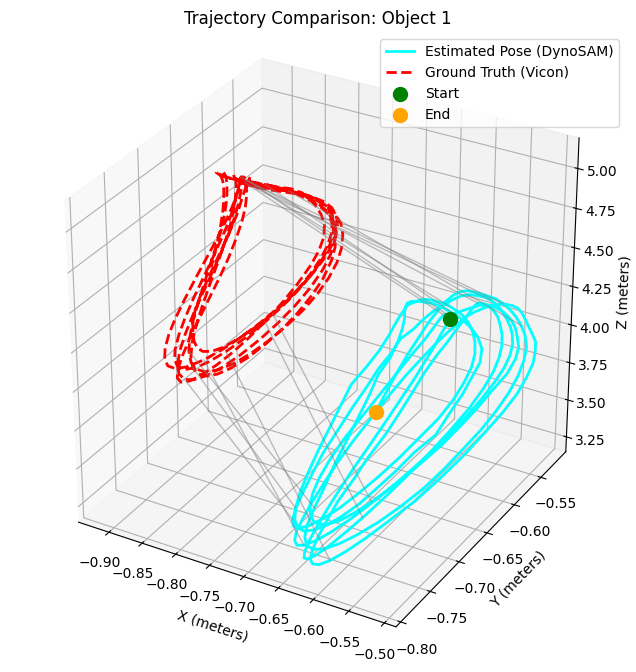

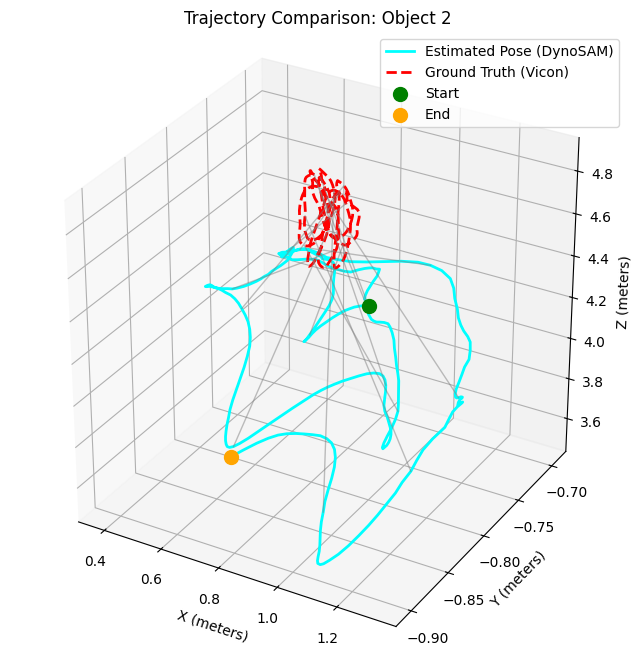

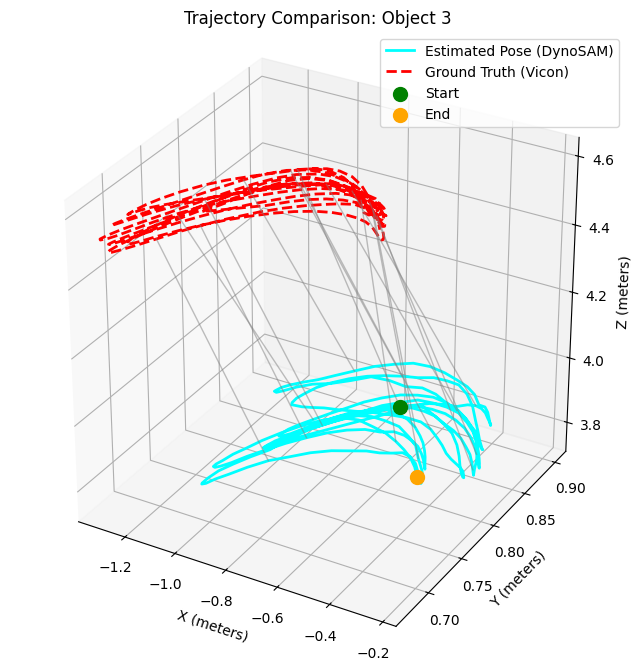

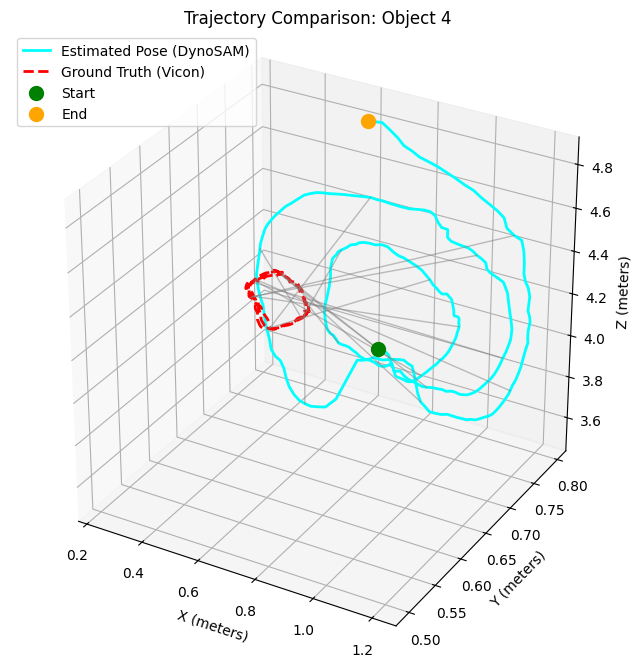

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_pose_comparison(csv_path, object_id=1):
    # Load data
    df = pd.read_csv(csv_path)
    
    # Filter for the specific object
    df_obj = df[df['object_id'] == object_id].sort_values('frame_id')
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. Plot Estimated Path
    ax.plot(df_obj['tx'], df_obj['ty'], df_obj['tz'], 
            label='Estimated Pose (DynoSAM)', color='cyan', linewidth=2)
    
    # 2. Plot Ground Truth Path
    ax.plot(df_obj['gt_tx'], df_obj['gt_ty'], df_obj['gt_tz'], 
            label='Ground Truth (Vicon)', color='red', linestyle='--', linewidth=2)
    
    # 3. Mark Start and End points
    ax.scatter(df_obj['tx'].iloc[0], df_obj['ty'].iloc[0], df_obj['tz'].iloc[0], 
               color='green', s=100, label='Start')
    ax.scatter(df_obj['tx'].iloc[-1], df_obj['ty'].iloc[-1], df_obj['tz'].iloc[-1], 
               color='orange', s=100, label='End')

    # Add Error Lines (Visualizing the "Ghosting" distance at intervals)
    # We plot a line between Est and GT every 20 frames
    for i in range(0, len(df_obj), 20):
        ax.plot([df_obj['tx'].iloc[i], df_obj['gt_tx'].iloc[i]],
                [df_obj['ty'].iloc[i], df_obj['gt_ty'].iloc[i]],
                [df_obj['tz'].iloc[i], df_obj['gt_tz'].iloc[i]], 
                color='gray', alpha=0.5, linewidth=1)

    # Labeling
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_zlabel('Z (meters)')
    ax.set_title(f'Trajectory Comparison: Object {object_id}')
    ax.legend()
    
    # Set equal scaling to avoid distortion
    # Matplotlib 3.3.0+ helper
    ax.set_box_aspect([1,1,1]) 
    
    plt.show()

# Run the comparison
plot_pose_comparison(f'{PATH}/../results/exp1/frontend_object_pose_log.csv', object_id=1)
plot_pose_comparison(f'{PATH}/../results/exp1/frontend_object_pose_log.csv', object_id=2)
plot_pose_comparison(f'{PATH}/../results/exp1/frontend_object_pose_log.csv', object_id=3)
plot_pose_comparison(f'{PATH}/../results/exp1/frontend_object_pose_log.csv', object_id=4)

In [28]:
outputs_ptm = torch.load("sam3d_object_cache_ptmp_input.pt")
outputs_noptm = torch.load("sam3d_object_cache_2.pt")
print(len(outputs_ptm[0]['glb'].vertices))
print(len(outputs_noptm[0]['glb'].vertices))

/tmp/ipykernel_1001/2067375644.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  outputs_ptm = torch.load("sam3d_object_cache_ptmp_input.pt")
/tmp/ipykernel_1001/206737564

175846
3388
